In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

## Importation du jeu de données

In [2]:
x_train = pd.read_csv('data/x_train.csv')
y_train = pd.read_csv('data/y_train.csv')
x_test = pd.read_csv('data/x_test.csv')

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (202933, 14)
y_train shape: (202933, 24)
x_test shape: (134673, 14)


In [3]:
x_train.head()

,ID,Humidity,M12,M13,M14,M15,M4,M5,M6,M7,R,S1,S2,S3
0,0,0.098160,-0.175981,-0.086469,-0.041465,-0.021153,0.197597,0.054646,-0.009277,0.001855,1.007242,1.013007,1.000563,0.999397
1,1,0.000307,-0.066416,0.036071,0.032636,-0.000573,2.568494,1.883142,0.779251,0.262231,0.971428,0.996735,1.002226,1.013063
2,2,0.000388,0.190943,0.187540,0.143680,0.092635,-0.147460,-0.021174,0.040079,0.065790,1.302238,0.905275,0.953600,0.986347
3,3,0.761003,-0.151393,-0.083723,-0.048982,-0.018259,0.045380,0.102427,0.012915,0.004453,1.013741,1.004315,1.012301,1.009465
4,4,0.107808,0.074818,0.042692,0.026169,0.019134,-0.056284,-0.011193,0.010233,0.012205,0.998659,1.005154,1.000096,0.999553


In [4]:
y_train.head()

,ID,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c14,c15,c16,c17,c18,c19,c20,c21,c22,c23
0,0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
1,1,0.000000,0.0,0.176471,0.176471,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.176471,0.0,0.0,0.176471,0.000000
2,2,0.128465,0.0,0.128465,0.128465,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.128465,0.000000,0.0,0.0,0.128465,0.000000
3,3,0.000000,0.0,0.263736,0.263736,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.263736,0.263736
4,4,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000


## Preprocessing

### Suppression des colonnes ID

In [5]:
x_test_without_id = x_test.drop(columns=["ID"])
x_train_without_id = x_train.drop(columns=["ID"])
y_train_without_id = y_train.drop(columns=["ID"])

In [7]:
x_train_without_id.head()

,Humidity,M12,M13,M14,M15,M4,M5,M6,M7,R,S1,S2,S3
0,0.098160,-0.175981,-0.086469,-0.041465,-0.021153,0.197597,0.054646,-0.009277,0.001855,1.007242,1.013007,1.000563,0.999397
1,0.000307,-0.066416,0.036071,0.032636,-0.000573,2.568494,1.883142,0.779251,0.262231,0.971428,0.996735,1.002226,1.013063
2,0.000388,0.190943,0.187540,0.143680,0.092635,-0.147460,-0.021174,0.040079,0.065790,1.302238,0.905275,0.953600,0.986347
3,0.761003,-0.151393,-0.083723,-0.048982,-0.018259,0.045380,0.102427,0.012915,0.004453,1.013741,1.004315,1.012301,1.009465
4,0.107808,0.074818,0.042692,0.026169,0.019134,-0.056284,-0.011193,0.010233,0.012205,0.998659,1.005154,1.000096,0.999553


### Analyse des valeurs manquantes

In [11]:
x_train_without_id.isna().sum()

Humidity    0
M12         0
M13         0
M14         0
M15         0
M4          0
M5          0
M6          0
M7          0
R           0
S1          0
S2          0
S3          0
dtype: int64

In [12]:
y_train_without_id.isna().sum()

c01    0
c02    0
c03    0
c04    0
c05    0
c06    0
c07    0
c08    0
c09    0
c10    0
c11    0
c12    0
c13    0
c14    0
c15    0
c16    0
c17    0
c18    0
c19    0
c20    0
c21    0
c22    0
c23    0
dtype: int64

### Analyse des corrélations de la matrice X

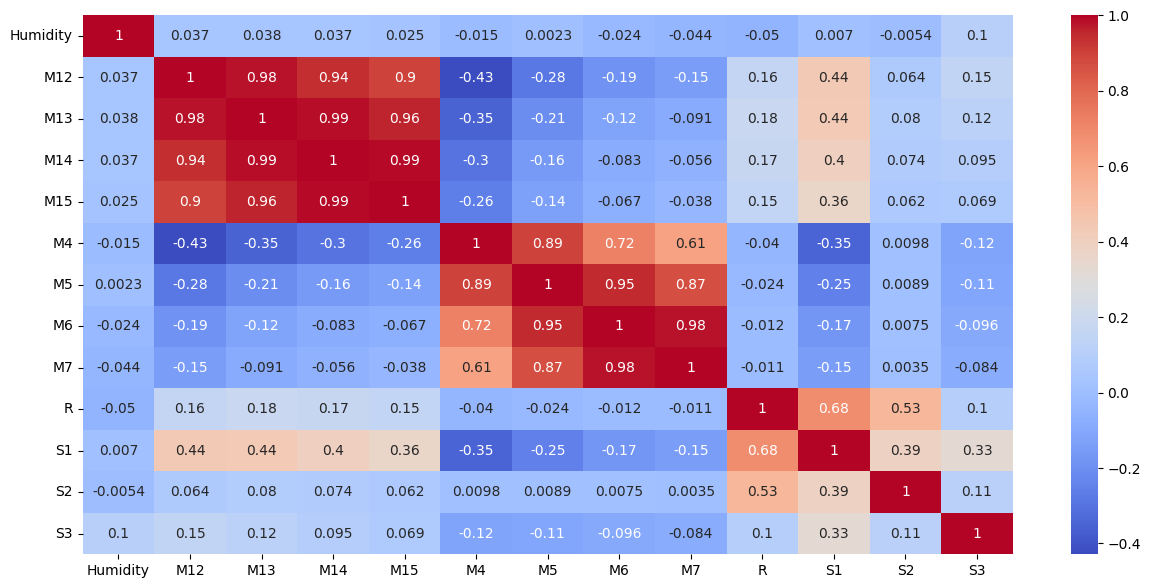

In [10]:
plt.figure(figsize=(15, 7))
sns.heatmap(x_train_without_id.corr(), annot=True, cmap='coolwarm');

On peut voir des cluster de fortes corrélation entre les données. (M12, M13, M14, M15) et (M4, M5, M6, M7). Il serait intéressant de faire une analyse en composante principale pour réduire la dimensionnalité des données.

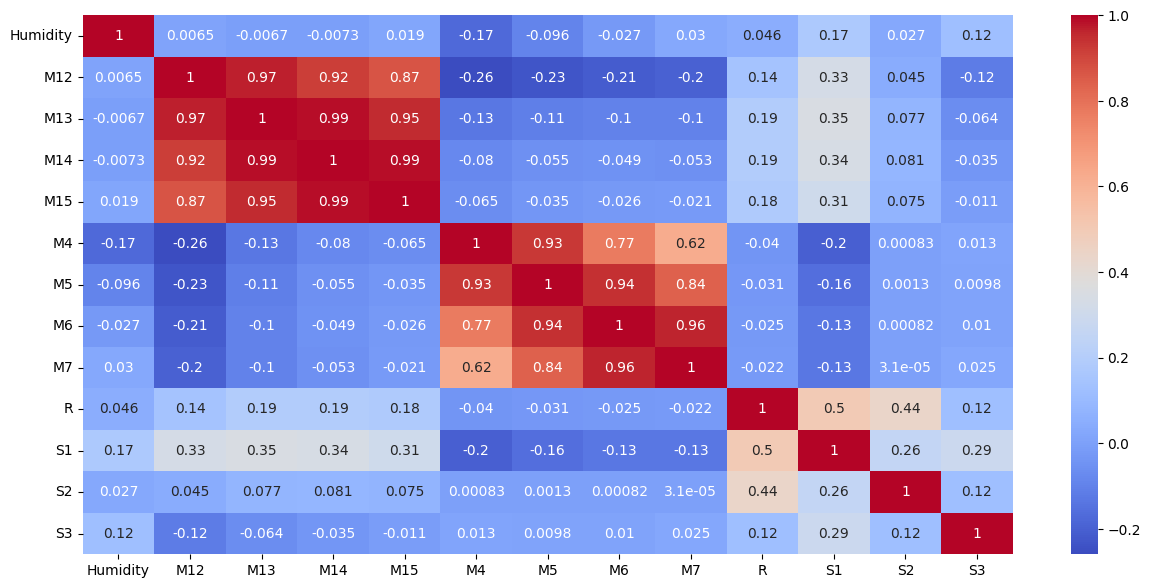

In [13]:
plt.figure(figsize=(15, 7))
sns.heatmap(x_test_without_id.corr(), annot=True, cmap='coolwarm');

On obtient les matrices de corrélation des features pour les datasets d'entrainement et de test. On peut voir que les deux matrices sont très similaires, ce qui est un bon signe pour la généralisation du modèle.

<Figure size 800x400 with 0 Axes>

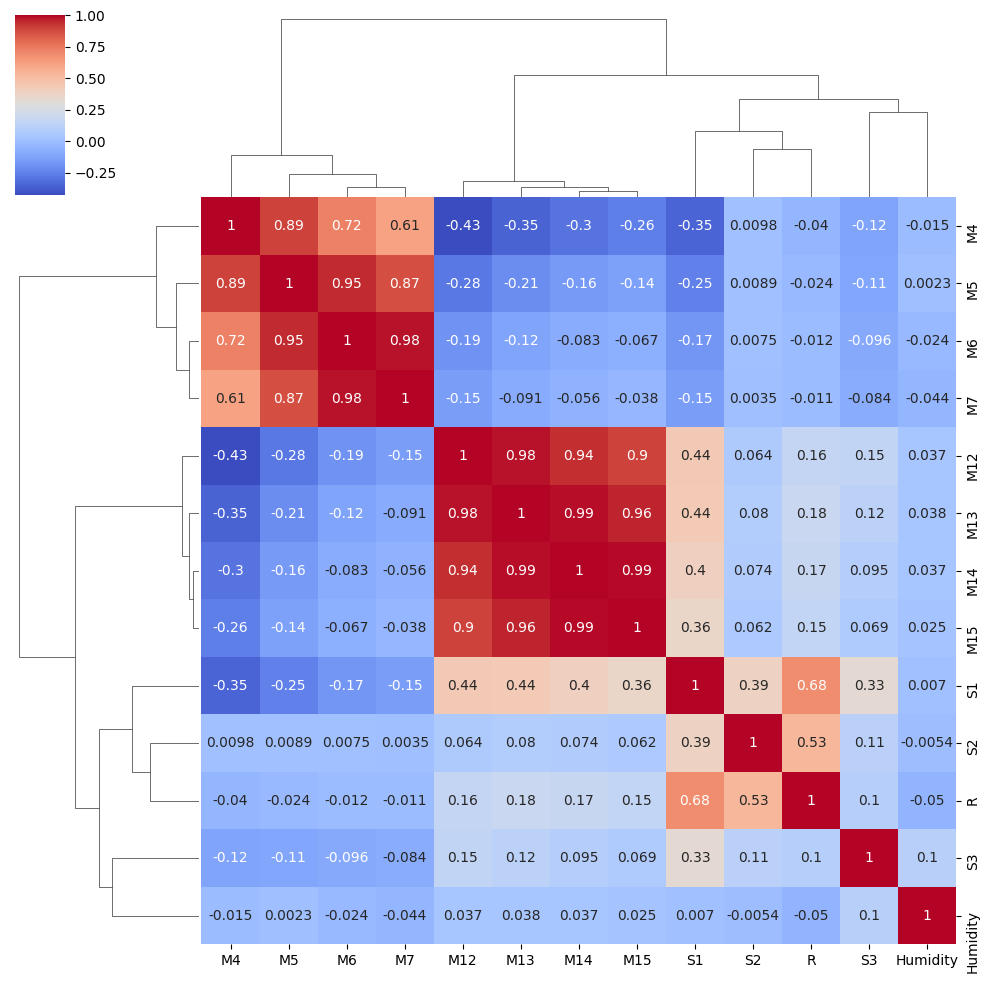

In [20]:
plt.figure(figsize=(8, 4))
sns.clustermap(x_train_without_id[["M4","M5","M6","M7","M12","M13","M14","M15","S1","S2","S3","R","Humidity"]].corr(), cmap='coolwarm', annot=True);


c15    1.000000
c16    0.994210
c08    0.989612
c19    0.978328
c09    0.973582
c17    0.956163
c23    0.949545
c06    0.945095
c05    0.945095
c21    0.945095
c11    0.878857
c10    0.858239
c13    0.851828
c07    0.847851
c02    0.847851
c20    0.847851
c14    0.801565
c12    0.792946
c18    0.781977
c01    0.462399
c04    0.107173
c03    0.107173
c22    0.107173
dtype: float64


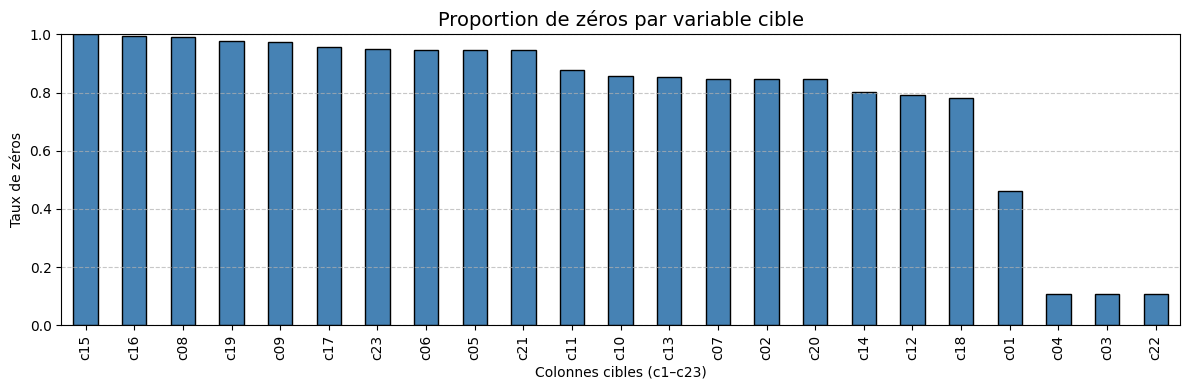

In [27]:

zero_rate = (y_train_without_id == 0).sum() / len(y_train)
zero_rate = zero_rate.sort_values(ascending=False)
print(zero_rate)
plt.figure(figsize=(12,4))
zero_rate.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Proportion de zéros par variable cible", fontsize=14)
plt.ylabel("Taux de zéros")
plt.xlabel("Colonnes cibles (c1–c23)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

On peut voir que certaine variables cibles ont une proportion très élevée de zéros, ce qui est très problématique et peut biaiser les résultats des modèles prédictifs. Une méthode serait pour le random forest regressor de supprimer ces variables presque nulle partout et de les remettre à 0 à la fin. Le souci est que pour ces gaz rare on aura pas de détéction possible. Une autre solution est de supprimer seulement c15 car nulle partout et de concerver les autres mais on risque de réduire drastiquement les performances du modèle. Une autre solution est de combiner un model de regressio et un modèle de classification. En effet le challenge se transforme en devoir detecter si ces gaz sont présent ou non. 

In [43]:
def create_submission(y_pred: np.ndarray, output_filename: str):
    """
    Génère un fichier de soumission à partir des prédictions d'un modèle.
    
    Paramètres
    ----------
    y_pred : np.ndarray
        Tableau numpy de taille (n_samples, 23) contenant les prédictions.
    output_filename : str
        Nom du fichier CSV de sortie.
    """
    x_test_temp = pd.read_csv("data/x_test.csv")
    test_id = x_test_temp["ID"]
    if y_pred.shape[0] != len(test_id):
        raise ValueError(f"Le nombre de prédictions ({y_pred.shape[0]}) "
                         f"ne correspond pas au nombre d'IDs ({len(test_id)})")
    if y_pred.shape[1] != 23:
        raise ValueError(f"y_pred doit avoir 23 colonnes, trouvé {y_pred.shape[1]}")
    submission = pd.DataFrame(y_pred, columns=[f"c{i}" for i in range(1, 24)])
    submission.insert(0, "ID", test_id)
    submission.to_csv(f"submission_{output_filename}", index=False)
    print(f"Fichier de soumission généré : {output_filename}")

In [44]:
def custom_metric(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    f = np.where(y_true < 0.5, 1.0, 1.2)
    errors = np.mean(f * (y_pred - y_true) ** 2, axis=1)
    return np.sqrt(np.mean(errors))

In [ ]:
def load_and_preprocess_data(x_train_path: str, y_train_path: str, x_test_path: str, zero_threshold: float = 0.9999, n_components_pca: int = 1):
    X_train = pd.read_csv(x_train_path)
    X_test = pd.read_csv(x_test_path)
    y_train = pd.read_csv(y_train_path)
    
    X_train.drop(columns=["ID"], inplace=True)
    X_test.drop(columns=["ID"], inplace=True)

    zero_rate = (y_train == 0).sum() / len(y_train)
    removed_targets = zero_rate[zero_rate > zero_threshold].index.tolist()
    y_train_filtered = y_train.drop(columns=removed_targets)
    
    groups = {
        "M_group1": ["M4", "M5", "M6", "M7"],
        "M_group2": ["M12", "M13", "M14", "M15"],
        "S_group": ["S1", "S2", "S3", "R"]
    }
    def apply_group_pca(df, n_components):
        df_pca = df.copy()
        for name, cols in groups.items():
            pca = PCA(n_components=n_components, random_state=42)
            components = pca.fit_transform(df[cols])
            for i in range(n_components):
                df_pca[f"{name}_PCA{i+1}"] = components[:, i]
            df_pca.drop(columns=cols, inplace=True)
        return df_pca
    X_train_pca = apply_group_pca(X_train, n_components_pca)
    X_test_pca = apply_group_pca(X_test, n_components_pca)
    print(f"Shape finale : {X_train_pca.shape[1]} features : {y_train_filtered.shape[1]} targets")

    return X_train_pca, X_test_pca, y_train_filtered, removed_targets

In [41]:
x_train_pca, x_test_pca, y_train_filtered, removed_targets = load_and_preprocess_data(
    x_train_path="data/x_train.csv",
    y_train_path="data/y_train.csv",
    x_test_path="data/x_test.csv",
    zero_threshold=0.9999,
    n_components_pca=2
)

Shape finale : 7 features : 23 targets


In [45]:
x_train_pca

,Humidity,M_group1_PCA1,M_group1_PCA2,M_group2_PCA1,M_group2_PCA2,S_group_PCA1,S_group_PCA2
0,0.098160,-0.824743,0.029141,0.230495,-0.037620,-0.153803,0.055844
1,0.000307,2.268696,0.265597,0.410705,-0.047443,-0.187273,0.072609
2,0.000388,-1.128414,0.222021,0.734793,-0.016020,0.082838,-0.103231
3,0.761003,-0.919127,0.150772,0.246243,-0.018634,-0.144010,0.064244
4,0.107808,-1.060899,0.144737,0.510834,0.040942,-0.162601,0.059220
...,...,...,...,...,...,...,...
202928,0.000393,-1.075032,0.133908,0.470854,0.037970,-0.162178,0.058735
202929,0.098254,0.706859,-0.331213,0.337101,-0.014607,-0.195393,0.061018
202930,0.097347,-1.147381,0.153803,0.401754,0.015290,-0.160520,0.059194
202931,0.000337,13.768897,-5.240464,-11.656288,0.760449,-0.923071,0.389708


In [ ]:
def evaluate_model(model, X_train: pd.DataFrame, y_train: pd.DataFrame , n_splits: int = 5):
    """
    Évalue le modèle par validation croisée selon la métrique custom.
    """
    scorer = make_scorer(custom_metric, greater_is_better=False)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=scorer, n_jobs=-1)
    print(f"Score moyen (custom metric) : {-np.mean(scores):.6f}")
    return -np.mean(scores)

In [51]:
model = train_random_forest(x_train_pca, y_train_filtered)

In [53]:
evaluate_model(model, x_train_pca, y_train_filtered, n_splits=2)

KeyboardInterrupt: 

In [ ]:
def train_random_forest(X_train: pd.DataFrame, y_train: pd.DataFrame):
    """
    Entraîne un RandomForestRegressor multi-output en deux étapes :
    1. RandomizedSearchCV large
    2. GridSearchCV locale autour des meilleurs paramètres
    """
    param_distributions = {
        'n_estimators': [100, 200, 300, 400, 500],
        'max_depth': [10, 15, 20, 25, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4, 6],
        'max_features': ['sqrt', 'log2', None]
    }
    scorer = make_scorer(custom_metric, greater_is_better=False)
    base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    print("Étape 1 : RandomizedSearchCV - Exploration large...")
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=15,
        scoring=scorer,
        cv=3,
        verbose=2,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)

    best_random_params = random_search.best_params_
    print(f"Meilleurs paramètres RandomizedSearch : {best_random_params}")
    def around(value, step, n=3):
        """Crée une petite grille centrée autour d’une valeur numérique."""
        if value is None:
            return [None]
        if isinstance(value, int):
            return sorted(list(set([max(1, value - step), value, value + step])))
        return [value]
    grid_params = {
        'n_estimators': around(best_random_params.get('n_estimators', 300), 100),
        'max_depth': around(best_random_params.get('max_depth', 20), 5),
        'min_samples_split': around(best_random_params.get('min_samples_split', 5), 1),
        'min_samples_leaf': around(best_random_params.get('min_samples_leaf', 3), 1),
        'max_features': [best_random_params.get('max_features', 'sqrt')]
    }
    print("Étape 2 : GridSearchCV - Raffinement local...")
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=grid_params,
        scoring=scorer,
        cv=3,
        verbose=2,
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    best_grid_params = grid_search.best_params_
    print(f"Meilleurs paramètres GridSearch : {best_grid_params}")
    print("Entraînement du modèle final avec les paramètres optimaux...")
    final_model = RandomForestRegressor(
        **best_grid_params,
        n_jobs=-1,
        random_state=42
    )
    final_model.fit(X_train, y_train)

    print("Modèle final entraîné avec succès.")
    return final_model, best_random_params, best_grid_params


In [ ]:
model = train_random_forest(x_train_pca, y_train_filtered)